### Optimizing the BPE algorithm

Making a new dictionary for the pair counts on the text every time, and then using the merge function makes the entire training process very slow. So, instead of doing this every time, we make the dictionary once, use the merge algorithm once, after that, we just update the pair counts affected by the merge, and nothing else.

Example:

cfdabghffababababababfahcbdja

pair = 'ab', replaced with 'X'

cfdXghffXXXXXXfahcbdja

now, we know we have to only check chars that are neighbours of the new token 'X'.

so, we check d [left of X], so 'da' is a pair which is no more. Hence dict[da] - 1.
Same for g, 'bg' was a pair which is no more, so bg(count) - 1.

if there are multiple new tokens together, we should ignore all the ones in between the leftmost and rightmost.

Also, obviously, once a pair is replaced, its count is replaced with 0.

In [31]:
new_vocab_list = ["X", "Y", "Z", "O", "P", "Q", "R", "S", "T", "U", "V", "W"]

In [32]:
import random
import timeit
import matplotlib.pyplot as plt


def naive_bpe(text):

    def get_stats(text):
        count = {}

        for pair in zip(text, text[1:]):
            count[pair] = count.get(pair, 0) + 1

        return count

    def merge(text, new, pair):
        new_text = ""
        i = 0

        while i < len(text):
            if i < len(text) - 1 and text[i] == pair[0] and text[i + 1] == pair[1]:
                new_text += new
                i += 2
            else:
                new_text += text[i]
                i += 1

        return new_text

    def train(text):
        merges = {}

        for i in range(len(new_vocab_list)):
            stats = get_stats(text)
            max_pair = max(stats, key=stats.get)
            new_char = new_vocab_list[i]

            new_text = merge(
                text,
                new_char,
                max_pair
            )

            merges[max_pair] = new_char
            text = new_text

        return text, merges

    return train(text)


In [38]:

def optimized_bpe(text):

    def get_stats(text):
        count = {}

        for pair in zip(text, text[1:]):
            count[pair] = count.get(pair, 0) + 1

        return count

    def get_max_pair(text, counts):
        max_pair = None
        max_count = -1

        for pair in zip(text, text[1:]):
            if counts[pair] > max_count:
                max_pair = pair
                max_count = counts[pair]

        return max_pair

    def merge(text, new, pair):
        new_text = ""
        i = 0
        num_merges = 0
        indices = []

        while i < len(text):
            if i < len(text) - 1 and text[i] == pair[0] and text[i + 1] == pair[1]:
                indices.append(i)
                new_text += new
                i += 2
                num_merges += 1
            else:
                new_text += text[i]
                i += 1

        return new_text, indices, num_merges

    def change_dict(counts, text, indices, pair, new):
        i = 0

        while i < len(indices):

            start = indices[i]
            end = start

            while i + 1 < len(indices) and indices[i + 1] == indices[i] + 2:
                i += 1
                end = indices[i]

            num_merges = ((end - start) // 2) + 1

            counts[pair] -= num_merges

            internal_pairs = num_merges - 1

            if internal_pairs > 0:
                middle_pair = (pair[1], pair[0])
                counts[middle_pair] -= internal_pairs

                new_new_pair = (new, new)
                counts[new_new_pair] = (
                    counts.get(new_new_pair, 0)
                    + internal_pairs
                )

            if start > 0:

                left_pair = (text[start - 1], pair[0])
                counts[left_pair] -= 1

                new_left_pair = (text[start - 1], new)
                counts[new_left_pair] = (
                    counts.get(new_left_pair, 0) + 1
                )

            if end + 2 < len(text):

                right_pair = (pair[1], text[end + 2])
                counts[right_pair] -= 1

                new_right_pair = (new, text[end + 2])
                counts[new_right_pair] = (
                    counts.get(new_right_pair, 0) + 1
                )

            i += 1

        counts = {
            pair: count
            for pair, count in counts.items()
            if count > 0
        }

        return counts

    def train(text):
        merges = {}

        stats = get_stats(text)
        max_pair = get_max_pair(text, stats)

        for i in range(len(new_vocab_list)):
            new_char = new_vocab_list[i]
            old_text = text

            new_text, indices, num_merges = merge(
                old_text,
                new_char,
                max_pair
            )

            merges[max_pair] = new_char

            stats = change_dict(
                stats,
                old_text,
                indices,
                max_pair,
                new_char
            )

            text = new_text
            max_pair = get_max_pair(text, stats)

        return text, merges

    return train(text)

Length:   1000 | Naive: 0.003092s | Optimized: 0.003694s | Speedup: 0.84x
Length:   5000 | Naive: 0.018538s | Optimized: 0.016729s | Speedup: 1.11x
Length:  10000 | Naive: 0.039396s | Optimized: 0.036663s | Speedup: 1.07x
Length:  25000 | Naive: 0.102720s | Optimized: 0.101886s | Speedup: 1.01x
Length:  50000 | Naive: 0.180311s | Optimized: 0.171403s | Speedup: 1.05x
Length:  75000 | Naive: 0.254717s | Optimized: 0.240740s | Speedup: 1.06x
Length: 100000 | Naive: 0.328072s | Optimized: 0.308662s | Speedup: 1.06x
Length: 125000 | Naive: 0.422808s | Optimized: 0.403355s | Speedup: 1.05x
Length: 150000 | Naive: 0.504535s | Optimized: 0.476079s | Speedup: 1.06x
Length: 200000 | Naive: 0.642448s | Optimized: 0.583432s | Speedup: 1.10x
Length: 225000 | Naive: 0.738375s | Optimized: 0.698491s | Speedup: 1.06x
Length: 250000 | Naive: 0.849977s | Optimized: 0.745990s | Speedup: 1.14x
Length: 275000 | Naive: 0.925770s | Optimized: 0.883722s | Speedup: 1.05x
Length: 300000 | Naive: 0.969203s | Op

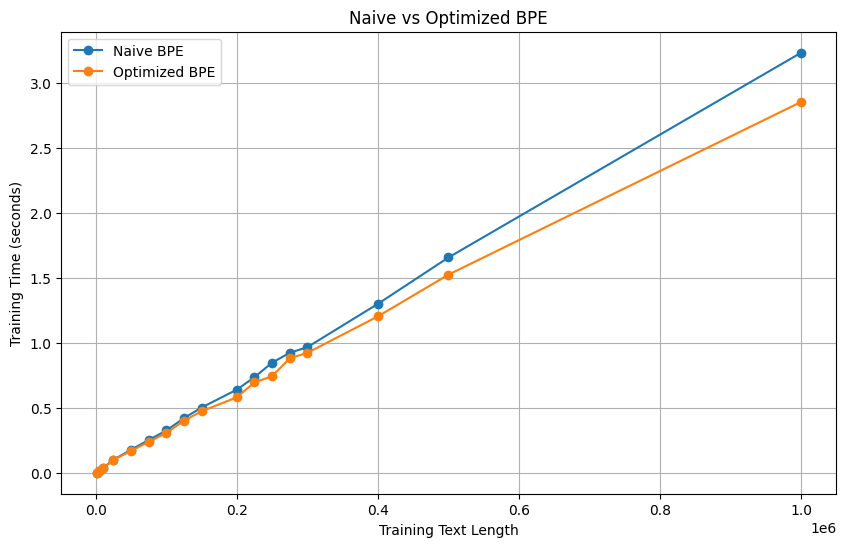

In [39]:
def compare_bpe():

    random.seed(42)

    initial_vocab = [
        "a", "b", "c", "d",
        "e", "f", "g", "h"
    ]

    text_lengths = [
        1000,
        5000,
        10000,
        25000,
        50000,
        75000,
        100000,
        125000,
        150000,
        200000,
        225000,
        250000,
        275000,
        300000,
        400000,
        500000,
        1000000
    ]

    naive_times = []
    optimized_times = []

    train_text = ""

    for _ in range(max(text_lengths)):
        train_text += random.choice(initial_vocab)

    for length in text_lengths:

        test_text = train_text[:length]

        start = timeit.default_timer()
        naive_text, naive_merges = naive_bpe(test_text)
        end = timeit.default_timer()

        naive_time = end - start

        start = timeit.default_timer()
        optimized_text, optimized_merges = optimized_bpe(test_text)
        end = timeit.default_timer()

        optimized_time = end - start

        assert naive_merges == optimized_merges
        assert naive_text == optimized_text

        naive_times.append(naive_time)
        optimized_times.append(optimized_time)

        print(
            f"Length: {length:>6} | "
            f"Naive: {naive_time:.6f}s | "
            f"Optimized: {optimized_time:.6f}s | "
            f"Speedup: {naive_time / optimized_time:.2f}x"
        )

    return text_lengths, naive_times, optimized_times


text_lengths, naive_times, optimized_times = compare_bpe()


plt.figure(figsize=(10, 6))

plt.plot(
    text_lengths,
    naive_times,
    marker="o",
    label="Naive BPE"
)

plt.plot(
    text_lengths,
    optimized_times,
    marker="o",
    label="Optimized BPE"
)

plt.xlabel("Training Text Length")
plt.ylabel("Training Time (seconds)")
plt.title("Naive vs Optimized BPE")
plt.legend()
plt.grid()

plt.show()

As we can see, this optimization does not work. One Idea is to use an inverted-index and frequency optimization.

Basically, after chunking the text using the REGEX, we make a frequency map of all chunks, we perform the max-pair count ONLY on the unique chunks, then perform merges only on the chunks affected. Idea used from this blog[https://deepbansal.info/blog/byte-pair-encoding-in-python]

Now we will compare naive, my optimization and this method on a sizable, multilingual text corpora.

In [5]:
import os
import sys
from pathlib import Path

project_root = next(
	path for path in [Path.cwd(), *Path.cwd().parents]
	if (path / "scripts" / "data_collection.py").is_file()
)

sys.path.insert(0, str(project_root))

from scripts.data_collection import DataCollector
import os

current = os.getcwd()
root = os.path.join(current, "..")
benchmark_dataset = os.path.join(root, "datasets", "benchmark_dataset")
os.makedirs(benchmark_dataset, exist_ok=True)

output_file = os.path.join(benchmark_dataset, "output.txt")
report_file = os.path.join(benchmark_dataset, "report.txt")

dataObj = DataCollector(output_file, report_file)
dataObj.add_language("english", 1, 1)
dataObj.add_language("hindi", 1, 1)
dataObj.add_language("japanese", 1, 1)
dataObj.add_language("french", 1, 1)
dataObj.add_programming_language("python", 1, 1)
dataObj.add_programming_language("cpp", 1, 1)
dataObj.add_programming_language("rust", 1, 1)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Jash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
Iterating over news RSS feeds::   0%|          | 0/4 [00:00<?, ?it/s]

Error processing article https://www.foxnews.com/world/fire-aboard-cargo-ship-undergoing-repairs-busy-chinese-port-leaves-25-people-dead-five-more-injured: Article `download()` failed with 403 Client Error: Forbidden 1002 for url: https://www.foxnews.com/world/fire-aboard-cargo-ship-undergoing-repairs-busy-chinese-port-leaves-25-people-dead-five-more-injured on URL https://www.foxnews.com/world/fire-aboard-cargo-ship-undergoing-repairs-busy-chinese-port-leaves-25-people-dead-five-more-injured
Error processing article https://www.foxnews.com/world/how-9-11-transformed-synagogue-security-new-reality-jewish-community: Article `download()` failed with 403 Client Error: Forbidden 1002 for url: https://www.foxnews.com/world/how-9-11-transformed-synagogue-security-new-reality-jewish-community on URL https://www.foxnews.com/world/how-9-11-transformed-synagogue-security-new-reality-jewish-community
Error processing article https://www.foxnews.com/world/drone-nearly-strikes-zelenskyy-plane-takeo

Iterating over news RSS feeds::  25%|██▌       | 1/4 [00:14<00:43, 14.38s/it]

Error processing article https://www.foxnews.com/world/fighter-jet-crashes-air-show-killing-2-pilots-thousands-spectators-watching: Article `download()` failed with 403 Client Error: Forbidden 1002 for url: https://www.foxnews.com/world/fighter-jet-crashes-air-show-killing-2-pilots-thousands-spectators-watching on URL https://www.foxnews.com/world/fighter-jet-crashes-air-show-killing-2-pilots-thousands-spectators-watching


Iterating over news RSS feeds::  75%|███████▌  | 3/4 [01:35<00:31, 31.93s/it]

...

Iterating over news RSS feeds:: 100%|██████████| 4/4 [01:19<00:00, 14.13s/it]

Error processing article https://www.ouest-france.fr/leditiondusoir/2026-09-10/une-veritable-heroine-comment-une-chienne-a-sauve-son-maitre-aveugle-coince-dans-une-tour-du-world-trade-center-5e1c8e40-6ead-4bc8-9ecf-aca6c4c25d99?utm_source=fluxpublicactu&utm_medium=fluxrss&utm_campaign=banquedecontenu: Article `download()` failed with 403 Client Error: Forbidden for url: https://www.ouest-france.fr/leditiondusoir/2026-09-10/une-veritable-heroine-comment-une-chienne-a-sauve-son-maitre-aveugle-coince-dans-une-tour-du-world-trade-center-5e1c8e40-6ead-4bc8-9ecf-aca6c4c25d99?utm_source=fluxpublicactu&utm_medium=fluxrss&utm_campaign=banquedecontenu on URL https://www.ouest-france.fr/leditiondusoir/2026-09-10/une-veritable-heroine-comment-une-chienne-a-sauve-son-maitre-aveugle-coince-dans-une-tour-du-world-trade-center-5e1c8e40-6ead-4bc8-9ecf-aca6c4c25d99?utm_source=fluxpublicactu&utm_medium=fluxrss&utm_campaign=banquedecontenu


Iterating over Wikipedia Shards::   0%|          | 0/17 [00:00<?, ?it/s]


Added french to data file.


Iterating over Repositories::  11%|█         | 1/9 [01:03<08:26, 63.31s/it]


In [9]:
import regex as re
import time
from collections import Counter, defaultdict

CORPUS_PATH = output_file
REGEX_PATTERN = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
MERGE_COUNTS = [25, 50, 75, 100]
BASE_VOCAB_SIZE = 256

def pretokenize(text, regex_pattern):
    
    pattern = re.compile(regex_pattern)
    chunks = pattern.findall(text)
    
    chunks = [
        list(chunk.encode("utf-8"))
        for chunk in chunks
    ]
    
    return chunks

# naive method

def get_best_pair(stats):
    
    return max(stats, key=lambda p: (stats[p], p))

def get_stats_naive(chunks):
    
    counts = {}
    
    for chunk in chunks:
        for pair in zip(chunk, chunk[1:]):
            counts[pair] = counts.get(pair, 0) + 1
            
    return counts

def merge_chunk(chunk, pair, new_token):
    
    new_chunk = []
    i = 0
    
    while i < len(chunk):
        
        if (i < len(chunk) - 1 and chunk[i] == pair[0] and chunk[i + 1] == pair[1]):
            new_chunk.append(new_token)
            i += 2
            
        else:
            new_chunk.append(chunk[i])
            i += 1
            
    return new_chunk
    
def train_naive(initial_chunks, num_merges):
    
    chunks = [chunk[:] for chunk in initial_chunks]
    merges = {}
    
    vocab = {idx: bytes([idx]) for idx in range(BASE_VOCAB_SIZE)}
    
    for i in range(num_merges):
        
        stats = get_stats_naive(chunks)
        
        if not stats:
            break
        
        pair = get_best_pair(stats)
        new_token = BASE_VOCAB_SIZE + i
        
        chunks = [merge_chunk(chunk, pair, new_token) for chunk in chunks]
        merges[pair] = new_token
        
        vocab[new_token] = (vocab[pair[0]] + vocab[pair[1]])
        
    return chunks, merges, vocab

# current optimization

def get_stats_once(chunks):
    
    counts = {}
    
    for chunk in chunks:
        for pair  in zip(chunk, chunk[1:]):
            counts[pair] = counts.get(pair, 0) + 1
            
    return counts

def find_pair_indices(chunk, pair):
    
    indices = []
    i = 0
    
    while i < len(chunk) - 1:
        
        if chunk[i] == pair[0] and chunk[i + 1] == pair[1]:
            indices.append(i)
            i += 2
        
        else:
            i += 1
            
    return indices

def merge_and_get_indices(chunk, pair, new_token):
    
    new_chunk = []
    indices = []
    
    i = 0
    
    while i < len(chunk):
        
        if (i < len(chunk) - 1 and chunk[i] == pair[0] and chunk[i + 1] == pair[1]):
            indices.append(i)
            new_chunk.append(new_token)
            i += 2
            
        else:
            new_chunk.append(chunk[i])
            i += 1
            
    return new_chunk, indices

def update_pair_counts_for_chunk(counts, old_chunk, new_chunk, pair, new_token):
    
    old_pairs = Counter(zip(old_chunk, old_chunk[1:]))
    new_pairs = Counter(zip(new_chunk, new_chunk[1:]))
    
    for p, count  in old_pairs.items():
        counts[p] -= count
        
    for p, count in new_pairs.items():
        counts[p] = counts.get(p, 0) + count
        
    zero_pairs = [p for p, count in counts.items() if count <= 0]
    
    for p in zero_pairs:
        del counts[p]
        
def train_optimized(initial_chunks, num_merges):
    
    chunks = [chunk[:] for chunk in initial_chunks]
    stats = get_stats_once(chunks)
    
    merges = {}
    vocab = {idx: bytes([idx]) for idx in range(BASE_VOCAB_SIZE)}
    
    for i in range(num_merges):
        
        if not stats:
            break
        
        pair = get_best_pair(stats)
        new_token = BASE_VOCAB_SIZE + i
        
        new_chunks = []
        
        for chunk in chunks:
            
            new_chunk, indices = merge_and_get_indices(chunk, pair, new_token)
            
            if indices:
                
                update_pair_counts_for_chunk(stats, chunk, new_chunk, pair, new_token)
                
            new_chunks.append(new_chunk)
            
        chunks = new_chunks
        merges[pair] = new_token
        
        vocab[new_token] = (vocab[pair[0]] + vocab[pair[1]])
        
    return chunks, merges, vocab

# inverted index + frequencies

def build_unique_chunks(initial_chunks):
    
    counter = Counter(tuple(chunk) for chunk in initial_chunks)
    
    unique_chunks = []
    frequencies = []
    
    for chunk, freq in counter.items():
        unique_chunks.append(list(chunk))
        frequencies.append(freq)
        
    return unique_chunks, frequencies

def build_inverted_index(unique_chunks, frequencies):
    
    pair_counts = Counter()
    pair_to_chunks = defaultdict(set)
    
    for chunk_idx, chunk in enumerate(unique_chunks):
        
        freq = frequencies[chunk_idx]
        
        for pair in zip(chunk, chunk[1:]):
            pair_counts[pair] += freq
            pair_to_chunks[pair].add(chunk_idx)
            
    return pair_counts, pair_to_chunks

def merge_unique_chunks(chunk, pair, new_token):
    
    new_chunk = []
    i = 0
    
    while i < len(chunk):
        
        if (i < len(chunk) - 1 and chunk[i] == pair[0] and chunk[i + 1] == pair[1]):
            new_chunk.append(new_token)
            i += 2
            
        else:
            new_chunk.append(chunk[i])
            i += 1
            
    return new_chunk

def train_inverted(initial_chunks, num_merges):
    
    unique_chunks, frequencies = build_unique_chunks(initial_chunks)
    pair_counts, pair_to_chunks = build_inverted_index(unique_chunks, frequencies)
    
    merges = {}
    vocab = {idx: bytes([idx]) for idx in range(BASE_VOCAB_SIZE)}
    
    for i in range(num_merges):
        
        if not pair_counts:
            break
        
        pair = get_best_pair(pair_counts)
        new_token = BASE_VOCAB_SIZE + i
        
        affected_chunks = list(pair_to_chunks.get(pair, set()))
        
        for chunk_idx in affected_chunks:
            old_chunk = unique_chunks[chunk_idx]
            freq = frequencies[chunk_idx]
            
            old_pairs = Counter(zip(old_chunk, old_chunk[1:]))
            
            for p, count in old_pairs.items():
                pair_counts[p] -= count * freq
                
                if pair_counts[p] <= 0:
                    del pair_counts[p]
                    
                if p in pair_to_chunks:
                    pair_to_chunks[p].discard(chunk_idx)
                    
                    if not pair_to_chunks[p]:
                        del pair_to_chunks[p]
                        
            new_chunk = merge_unique_chunks(old_chunk, pair, new_token)
            unique_chunks[chunk_idx] = new_chunk    
            new_pairs = Counter(zip(new_chunk, new_chunk[1:]))
            
            for p, count in new_pairs.items():

                pair_counts[p] += count * freq
                pair_to_chunks[p].add(chunk_idx)
                
        merges[pair] = new_token
        vocab[new_token] = (vocab[pair[0]] + vocab[pair[1]])
        
    expanded_chunks = []
    for chunk, freq in zip(unique_chunks, frequencies):

        for _ in range(freq):
            expanded_chunks.append(chunk[:])

    return expanded_chunks, merges, vocab



def compare_results(
    naive_result,
    optimized_result,
    inverted_result
):
   
    naive_chunks, naive_merges, naive_vocab = naive_result
    opt_chunks, opt_merges, opt_vocab = optimized_result
    inv_chunks, inv_merges, inv_vocab = inverted_result

    chunks_match = (
        Counter(map(tuple, naive_chunks))
        == Counter(map(tuple, opt_chunks))
        == Counter(map(tuple, inv_chunks))
    )

    merges_match = (
        naive_merges == opt_merges == inv_merges
    )

    vocab_match = (
        naive_vocab == opt_vocab == inv_vocab
    )

    return chunks_match, merges_match, vocab_match
                    
                    
def benchmark_algorithm(func, chunks, num_merges):

    start = time.perf_counter()

    result = func(
        chunks,
        num_merges
    )

    elapsed = time.perf_counter() - start

    return elapsed, result               



def main():

    print("=" * 70)
    print("Loading corpus")
    print("=" * 70)

    with open(
        CORPUS_PATH,
        "r",
        encoding="utf-8"
    ) as f:
        text = f.read()

    print(f"Corpus characters : {len(text):,}")
    print(
        f"Corpus size       : "
        f"{len(text.encode('utf-8')) / (1024 * 1024):.2f} MB"
    )

    print()
    print("=" * 70)
    print("Pretokenizing")
    print("=" * 70)

    start = time.perf_counter()

    chunks = pretokenize(
        text,
        REGEX_PATTERN
    )

    pretokenize_time = time.perf_counter() - start

    print(f"Number of chunks : {len(chunks):,}")
    print(f"Pretokenization  : {pretokenize_time:.4f} sec")

    unique_chunk_counter = Counter(
        tuple(chunk)
        for chunk in chunks
    )

    unique_chunks = len(unique_chunk_counter)
    total_chunks = len(chunks)

    unique_ratio = unique_chunks / total_chunks

    print()
    print("=" * 70)
    print("Corpus structure")
    print("=" * 70)

    print(f"Total chunks     : {total_chunks:,}")
    print(f"Unique chunks    : {unique_chunks:,}")
    print(f"Unique / total   : {unique_ratio:.4%}")
    print(
        f"Frequency saving : "
        f"{(1 - unique_ratio):.4%}"
    )

    results = []

    print()
    print("=" * 70)
    print("Benchmark")
    print("=" * 70)

    for num_merges in MERGE_COUNTS:

        print()
        print(f"Merges = {num_merges}")
        print("-" * 70)

        naive_time, naive_result = benchmark_algorithm(
            train_naive,
            chunks,
            num_merges
        )

        print(
            f"Naive       : {naive_time:.4f} sec"
        )

        optimized_time, optimized_result = benchmark_algorithm(
            train_optimized,
            chunks,
            num_merges
        )

        print(
            f"Your Opt    : {optimized_time:.4f} sec"
        )
        
        inverted_time, inverted_result = benchmark_algorithm(
            train_inverted,
            chunks,
            num_merges
        )

        print(
            f"Inverted    : {inverted_time:.4f} sec"
        )

        chunks_match, merges_match, vocab_match = compare_results(
            naive_result,
            optimized_result,
            inverted_result
        )

        print()
        print(
            f"Chunks same  : {'YES' if chunks_match else 'NO'}"
        )

        print(
            f"Merges same  : {'YES' if merges_match else 'NO'}"
        )

        print(
            f"Vocab same   : {'YES' if vocab_match else 'NO'}"
        )

        if not (
            chunks_match
            and merges_match
            and vocab_match
        ):
            print()
            print("!!! CORRECTNESS FAILURE !!!")

            break

        opt_speedup = naive_time / optimized_time
        inv_speedup = naive_time / inverted_time

        print()
        print(
            f"Your Opt speedup : {opt_speedup:.2f}x"
        )

        print(
            f"Inverted speedup : {inv_speedup:.2f}x"
        )

        results.append({
            "merges": num_merges,
            "naive_sec": naive_time,
            "optimized_sec": optimized_time,
            "inverted_sec": inverted_time,
            "optimized_speedup": opt_speedup,
            "inverted_speedup": inv_speedup,
        })

    print()
    print()
    print("=" * 90)
    print("FINAL RESULTS")
    print("=" * 90)

    print(
        f"{'Merges':>8} "
        f"{'Naive':>12} "
        f"{'Your Opt':>12} "
        f"{'Inverted':>12} "
        f"{'Opt Speedup':>14} "
        f"{'Inv Speedup':>14}"
    )

    print("-" * 90)

    for r in results:

        print(
            f"{r['merges']:>8} "
            f"{r['naive_sec']:>12.4f} "
            f"{r['optimized_sec']:>12.4f} "
            f"{r['inverted_sec']:>12.4f} "
            f"{r['optimized_speedup']:>13.2f}x "
            f"{r['inverted_speedup']:>13.2f}x"
        )


    return results


results = main()

Loading corpus
Corpus characters : 3,146,566
Corpus size       : 3.00 MB

Pretokenizing
Number of chunks : 824,418
Pretokenization  : 0.8397 sec

Corpus structure
Total chunks     : 824,418
Unique chunks    : 6,435
Unique / total   : 0.7806%
Frequency saving : 99.2194%

Benchmark

Merges = 25
----------------------------------------------------------------------
Naive       : 25.2599 sec
Your Opt    : 41.9792 sec
Inverted    : 0.6891 sec

Chunks same  : YES
Merges same  : YES
Vocab same   : YES

Your Opt speedup : 0.60x
Inverted speedup : 36.65x

Merges = 50
----------------------------------------------------------------------
Naive       : 48.1582 sec
Your Opt    : 69.1712 sec
Inverted    : 0.7667 sec

Chunks same  : YES
Merges same  : YES
Vocab same   : YES

Your Opt speedup : 0.70x
Inverted speedup : 62.81x

Merges = 75
----------------------------------------------------------------------
Naive       : 70.6819 sec
Your Opt    : 94.5945 sec
Inverted    : 0.3050 sec

Chunks same  : 

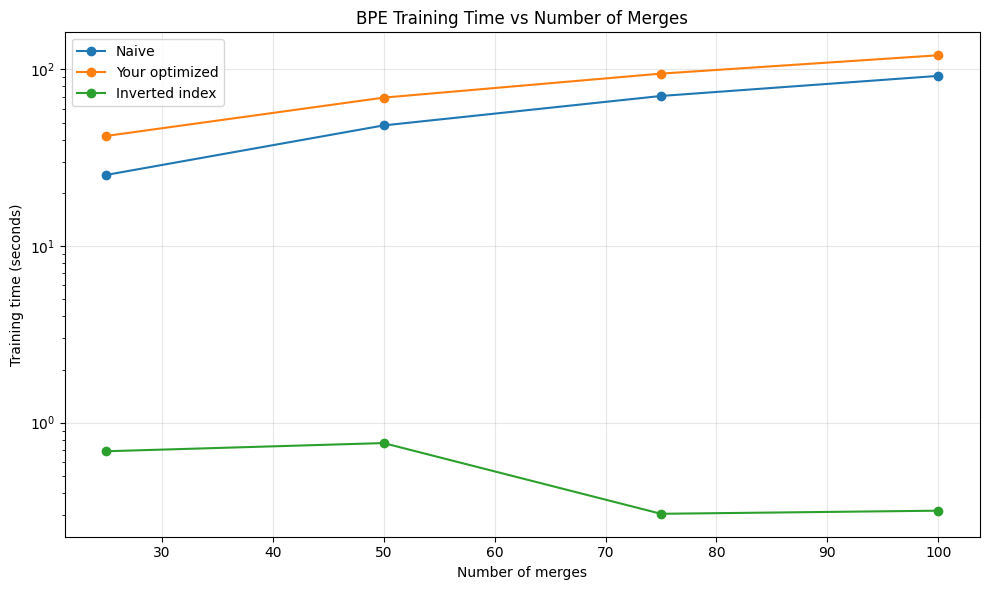

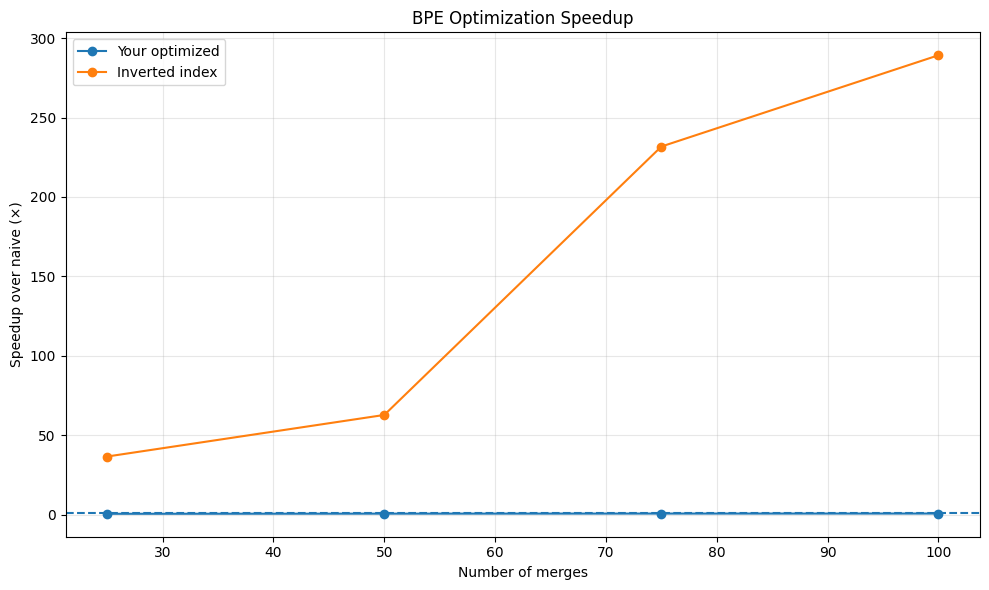

In [11]:
import matplotlib.pyplot as plt


def plot_results(results):
    merges = [r["merges"] for r in results]

    naive = [r["naive_sec"] for r in results]
    optimized = [r["optimized_sec"] for r in results]
    inverted = [r["inverted_sec"] for r in results]

    plt.figure(figsize=(10, 6))
    plt.yscale("log")

    plt.plot(
        merges,
        naive,
        marker="o",
        label="Naive"
    )

    plt.plot(
        merges,
        optimized,
        marker="o",
        label="Your optimized"
    )

    plt.plot(
        merges,
        inverted,
        marker="o",
        label="Inverted index"
    )

    plt.xlabel("Number of merges")
    plt.ylabel("Training time (seconds)")
    plt.title("BPE Training Time vs Number of Merges")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        "bpe_training_time.png",
        dpi=300
    )

    plt.show()

    opt_speedup = [
        r["optimized_speedup"]
        for r in results
    ]

    inv_speedup = [
        r["inverted_speedup"]
        for r in results
    ]

    plt.figure(figsize=(10, 6))

    plt.plot(
        merges,
        opt_speedup,
        marker="o",
        label="Your optimized"
    )

    plt.plot(
        merges,
        inv_speedup,
        marker="o",
        label="Inverted index"
    )

    plt.axhline(
        1,
        linestyle="--"
    )

    plt.xlabel("Number of merges")
    plt.ylabel("Speedup over naive (×)")
    plt.title("BPE Optimization Speedup")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        "bpe_speedup.png",
        dpi=300
    )

    plt.show()
    
plot_results(results)